
# Hidden Markov Models (HMM) from Scratch — with Viterbi (Google Colab)

**Objectives**
- Define a discrete Hidden Markov Model (HMM) formally.
- Implement a simulator to generate hidden state and observation sequences.
- Compute sequence likelihood via the **Forward** algorithm (normal domain and log space).
- Recover the most probable hidden-state sequence with the **Viterbi** algorithm (log space).
- Validate results on a canonical toy example and with brute-force checks for short sequences.
- Visualize Viterbi trellis scores.

> This notebook is self-contained and uses only NumPy and matplotlib (no specialized HMM libraries).



## 1. Setup and utilities
We import Python libraries and implement a few utilities (e.g., `logsumexp`) for numerical stability.


In [ ]:

# Imports
from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional
import numpy as np
import math
import itertools
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

def set_seed(seed: int = 0) -> None:
    np.random.seed(seed)

def row_stochastic_ok(M: np.ndarray, atol: float = 1e-8) -> bool:
    """Check each row sums to 1 within tolerance and entries are non-negative."""
    if (M < -atol).any():
        return False
    row_sums = M.sum(axis=1)
    return np.allclose(row_sums, 1.0, atol=atol)

def logsumexp(vec: np.ndarray) -> float:
    """Stable log-sum-exp for 1D arrays."""
    m = np.max(vec)
    if np.isneginf(m):
        return -np.inf
    return m + np.log(np.sum(np.exp(vec - m)))



## 2. Discrete HMM definition

We represent an HMM by:
- `states`: list of hidden state names, size `S`
- `observations`: list of observable symbol names, size `O`
- Transition matrix `A` of shape `(S, S)`, where `A[i, j] = P(s_t = j | s_{t-1} = i)`
- Emission matrix `B` of shape `(S, O)`, where `B[i, k] = P(o_t = k | s_t = i)`
- Initial distribution `pi` of shape `(S,)`, where `pi[i] = P(s_0 = i)`

All rows of `A`, `B` and the vector `pi` must be (approximately) stochastic.


In [ ]:

@dataclass
class HMM:
    states: List[str]
    observations: List[str]
    A: np.ndarray  # S x S
    B: np.ndarray  # S x O
    pi: np.ndarray # S

    def __post_init__(self) -> None:
        S = len(self.states)
        O = len(self.observations)
        assert self.A.shape == (S, S), f"A must be {S}x{S}"
        assert self.B.shape == (S, O), f"B must be {S}x{O}"
        assert self.pi.shape == (S,),  f"pi must be length {S}"
        assert row_stochastic_ok(self.A), "Rows of A must be (approximately) stochastic."
        assert row_stochastic_ok(self.B), "Rows of B must be (approximately) stochastic."
        assert math.isclose(self.pi.sum(), 1.0, rel_tol=1e-8, abs_tol=1e-8), "pi must sum to 1."
        assert (self.A >= -1e-12).all() and (self.B >= -1e-12).all() and (self.pi >= -1e-12).all()

    # Index maps for convenience
    @property
    def state_to_idx(self) -> Dict[str, int]:
        return {s: i for i, s in enumerate(self.states)}

    @property
    def obs_to_idx(self) -> Dict[str, int]:
        return {o: i for i, o in enumerate(self.observations)}

    def sample(self, T: int, seed: Optional[int] = None) -> Tuple[List[int], List[int]]:
        """
        Sample a length-T sequence of (hidden states, observations) indices.
        Returns (hidden_state_indices, observation_indices).
        """
        if seed is not None:
            set_seed(seed)
        S = len(self.states)
        O = len(self.observations)
        hidden = np.zeros(T, dtype=int)
        obs = np.zeros(T, dtype=int)

        # Initial state
        hidden[0] = np.random.choice(S, p=self.pi)
        obs[0] = np.random.choice(O, p=self.B[hidden[0]])

        # Transitions
        for t in range(1, T):
            hidden[t] = np.random.choice(S, p=self.A[hidden[t-1]])
            obs[t] = np.random.choice(O, p=self.B[hidden[t]])
        return hidden.tolist(), obs.tolist()



## 3. Forward algorithm (sequence likelihood)

Given an observation sequence $ o_{0:T-1} $, the forward algorithm computes
$ \alpha_t(i) = P(o_{0:t}, s_t = i) $ recursively and returns the total likelihood $ P(o_{0:T-1}) $.

We provide both a normal-domain version (fine for short sequences) and a log-domain version for
numerical stability on longer sequences.


In [ ]:

def forward_normal(hmm: HMM, obs_seq: List[int]) -> Tuple[float, np.ndarray]:
    """
    Forward algorithm in normal probability domain.
    Returns (likelihood, alpha[T x S]).
    """
    T = len(obs_seq)
    S = len(hmm.states)
    alpha = np.zeros((T, S), dtype=float)

    # Initialization
    o0 = obs_seq[0]
    alpha[0] = hmm.pi * hmm.B[:, o0]

    # Induction
    for t in range(1, T):
        ot = obs_seq[t]
        for j in range(S):
            alpha[t, j] = np.dot(alpha[t-1], hmm.A[:, j]) * hmm.B[j, ot]

    # Termination
    likelihood = float(alpha[-1].sum())
    return likelihood, alpha


def forward_log(hmm: HMM, obs_seq: List[int]) -> Tuple[float, np.ndarray]:
    """
    Forward algorithm in log domain.
    Returns (log_likelihood, log_alpha[T x S]).
    """
    T = len(obs_seq)
    S = len(hmm.states)
    logA = np.log(hmm.A + 1e-300)  # avoid log(0)
    logB = np.log(hmm.B + 1e-300)
    logpi = np.log(hmm.pi + 1e-300)

    log_alpha = np.full((T, S), -np.inf, dtype=float)
    # Initialization
    o0 = obs_seq[0]
    log_alpha[0] = logpi + logB[:, o0]

    # Induction
    for t in range(1, T):
        ot = obs_seq[t]
        for j in range(S):
            log_alpha[t, j] = logsumexp(log_alpha[t-1] + logA[:, j]) + logB[j, ot]

    # Termination
    log_likelihood = float(logsumexp(log_alpha[-1]))
    return log_likelihood, log_alpha



## 4. Viterbi algorithm (most probable hidden path)

The Viterbi algorithm computes the MAP state sequence
$\arg\max_{s_{0:T-1}} P(s_{0:T-1} \mid o_{0:T-1})$.
We implement it in log space using dynamic programming and backpointers.


In [ ]:

def viterbi_log(hmm: HMM, obs_seq: List[int]) -> Tuple[List[int], float, np.ndarray, np.ndarray]:
    """
    Viterbi in log domain.
    Returns (best_path_indices, best_path_logprob, delta[T x S], psi[T x S]).
      - delta[t, i] = best log-prob of any path ending in state i at time t
      - psi[t, i]   = argmax backpointer for state i at time t
    """
    T = len(obs_seq)
    S = len(hmm.states)
    logA = np.log(hmm.A + 1e-300)
    logB = np.log(hmm.B + 1e-300)
    logpi = np.log(hmm.pi + 1e-300)

    delta = np.full((T, S), -np.inf, dtype=float)
    psi = np.full((T, S), -1, dtype=int)

    # Initialization
    o0 = obs_seq[0]
    delta[0] = logpi + logB[:, o0]

    # Recursion
    for t in range(1, T):
        ot = obs_seq[t]
        for j in range(S):
            scores = delta[t-1] + logA[:, j]
            psi[t, j] = int(np.argmax(scores))
            delta[t, j] = scores[psi[t, j]] + logB[j, ot]

    # Termination
    best_last_state = int(np.argmax(delta[-1]))
    best_logprob = float(delta[-1, best_last_state])

    # Backtrace
    best_path = [best_last_state]
    for t in range(T-1, 0, -1):
        best_prev = psi[t, best_path[-1]]
        best_path.append(int(best_prev))
    best_path.reverse()
    return best_path, best_logprob, delta, psi



## 5. Canonical toy example

We use a classic 2-state weather model with 3 observation symbols:

- States: `Rainy`, `Sunny`
- Observations: `walk`, `shop`, `clean`

Parameters (from standard textbook examples):

$$
\pi = [0.6,\, 0.4],\quad
A = \begin{bmatrix}0.7 & 0.3\\ 0.4 & 0.6\end{bmatrix},\quad
B = \begin{bmatrix}
0.1 & 0.4 & 0.5\\
0.6 & 0.3 & 0.1
\end{bmatrix}
$$

Observation sequence: `walk, shop, clean`.


In [ ]:

# Define the toy HMM
states = ["Rainy", "Sunny"]
observations = ["walk", "shop", "clean"]
A = np.array([[0.7, 0.3],
              [0.4, 0.6]], dtype=float)
B = np.array([[0.1, 0.4, 0.5],
              [0.6, 0.3, 0.1]], dtype=float)
pi = np.array([0.6, 0.4], dtype=float)

hmm = HMM(states=states, observations=observations, A=A, B=B, pi=pi)

# Observation sequence: walk, shop, clean
obs_seq_names = ["walk", "shop", "clean"]
obs_seq = [hmm.obs_to_idx[o] for o in obs_seq_names]

print("Observation indices:", obs_seq)
print("Observation names:", obs_seq_names)


Observation indices: [0, 1, 2]
Observation names: ['walk', 'shop', 'clean']



### 5.1 Forward algorithm: likelihood
We compute the likelihood using both normal-domain and log-domain forward passes.


In [ ]:

lik_normal, alpha = forward_normal(hmm, obs_seq)
loglik, log_alpha = forward_log(hmm, obs_seq)

print("Forward (normal) likelihood:", lik_normal)
print("Forward (log)   log-likelihood:", loglik)
print("Forward (log)   likelihood via exp:", float(np.exp(loglik)))

print("Alpha (normal domain):", alpha)
print("Log-Alpha (log domain):", log_alpha)


Forward (normal) likelihood: 0.033612
Forward (log)   log-likelihood: -3.3928721329161653
Forward (log)   likelihood via exp: 0.033611999999999996
Alpha (normal domain): [[0.06   0.24  ]
 [0.0552 0.0486]
 [0.029  0.0046]]
Log-Alpha (log domain): [[-2.8134 -1.4271]
 [-2.8968 -3.0241]
 [-3.5391 -5.3878]]



### 5.2 Viterbi: most probable state sequence


Viterbi best path (indices): [1, 0, 0]
Viterbi best path (names): ['Sunny', 'Rainy', 'Rainy']
Viterbi best path log-prob: -4.309519943887134
Viterbi best path prob: 0.013439999999999999


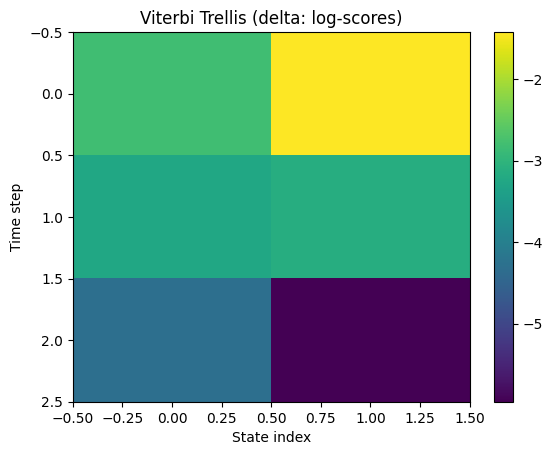

In [ ]:

best_path, best_logprob, delta, psi = viterbi_log(hmm, obs_seq)
best_path_names = [hmm.states[i] for i in best_path]

print("Viterbi best path (indices):", best_path)
print("Viterbi best path (names):", best_path_names)
print("Viterbi best path log-prob:", best_logprob)
print("Viterbi best path prob:", float(np.exp(best_logprob)))

# Visualize delta (trellis of scores)
plt.figure()
plt.imshow(delta, aspect='auto')
plt.title("Viterbi Trellis (delta: log-scores)")
plt.xlabel("State index")
plt.ylabel("Time step")
plt.colorbar()
plt.show()



## 6. Brute force validation for short sequences

For short horizons $T$, we can enumerate all $S^T$ hidden paths to validate both the
forward likelihood and Viterbi path.


In [ ]:

def joint_logprob(hmm: HMM, state_path: List[int], obs_seq: List[int]) -> float:
    """Compute log P(s_0:T-1, o_0:T-1) exactly for a concrete state path."""
    logA = np.log(hmm.A + 1e-300)
    logB = np.log(hmm.B + 1e-300)
    logpi = np.log(hmm.pi + 1e-300)
    T = len(obs_seq)
    lp = logpi[state_path[0]] + logB[state_path[0], obs_seq[0]]
    for t in range(1, T):
        i_prev, i_cur = state_path[t-1], state_path[t]
        lp += logA[i_prev, i_cur] + logB[i_cur, obs_seq[t]]
    return float(lp)

def brute_force_best_path(hmm: HMM, obs_seq: List[int]) -> Tuple[List[int], float]:
    S = len(hmm.states)
    T = len(obs_seq)
    best_lp = -np.inf
    best_path = None
    for path in itertools.product(range(S), repeat=T):
        lp = joint_logprob(hmm, list(path), obs_seq)
        if lp > best_lp:
            best_lp = lp
            best_path = list(path)
    return best_path, best_lp

bf_path, bf_logprob = brute_force_best_path(hmm, obs_seq)

print("Brute force best path (indices):", bf_path)
print("Brute force best path (names):", [hmm.states[i] for i in bf_path])
print("Brute force best path log-prob:", bf_logprob)
print("Viterbi matches brute force? ->", bf_path == best_path)

# Also validate sequence likelihood by summing over all paths
S = len(hmm.states)
T = len(obs_seq)
all_lp = []
for path in itertools.product(range(S), repeat=T):
    all_lp.append(joint_logprob(hmm, list(path), obs_seq))
log_lik_exact = logsumexp(np.array(all_lp, dtype=float))
print("Forward log-likelihood:", loglik)
print("Exact   log-likelihood (sum over all paths):", log_lik_exact)
print("Close? ->", math.isclose(loglik, log_lik_exact, rel_tol=1e-10, abs_tol=1e-10))


Brute force best path (indices): [1, 0, 0]
Brute force best path (names): ['Sunny', 'Rainy', 'Rainy']
Brute force best path log-prob: -4.309519943887134
Viterbi matches brute force? -> True
Forward log-likelihood: -3.3928721329161653
Exact   log-likelihood (sum over all paths): -3.3928721329161653
Close? -> True



## 7. Sampling from the HMM

We can sample a synthetic hidden-state/observation sequence and then run Viterbi to see how well
we recover the generating states.


In [ ]:

hidden_sample, obs_sample = hmm.sample(T=10, seed=42)
print("Sampled observation indices:", obs_sample)
print("Sampled observation names:", [hmm.observations[i] for i in obs_sample])
print("True hidden states indices:", hidden_sample)
print("True hidden states names:", [hmm.states[i] for i in hidden_sample])

v_path, v_logp, _, _ = viterbi_log(hmm, obs_sample)
print("Viterbi recovered states:", v_path)
print("Viterbi recovered names:", [hmm.states[i] for i in v_path])
acc = np.mean(np.array(v_path) == np.array(hidden_sample))
print(f"Token-wise accuracy vs. true hidden states: {acc:.2f}")


Sampled observation indices: [2, 0, 1, 2, 2, 2, 0, 1, 2, 1]
Sampled observation names: ['clean', 'walk', 'shop', 'clean', 'clean', 'clean', 'walk', 'shop', 'clean', 'shop']
True hidden states indices: [0, 1, 0, 0, 0, 0, 1, 0, 0, 0]
True hidden states names: ['Rainy', 'Sunny', 'Rainy', 'Rainy', 'Rainy', 'Rainy', 'Sunny', 'Rainy', 'Rainy', 'Rainy']
Viterbi recovered states: [0, 1, 0, 0, 0, 0, 1, 0, 0, 0]
Viterbi recovered names: ['Rainy', 'Sunny', 'Rainy', 'Rainy', 'Rainy', 'Rainy', 'Sunny', 'Rainy', 'Rainy', 'Rainy']
Token-wise accuracy vs. true hidden states: 1.00



## 8. Convenience helpers to work with strings

To make experimentation easier, we provide string-to-index and index-to-string conversions for arbitrary sequences.


In [ ]:

def obs_names_to_idx(hmm: HMM, obs_names: List[str]) -> List[int]:
    return [hmm.obs_to_idx[o] for o in obs_names]

def states_idx_to_names(hmm: HMM, path: List[int]) -> List[str]:
    return [hmm.states[i] for i in path]



## 9. Exercises & extensions (optional)

1. **Longer sequences**: Compare the numerical stability of `forward_normal` vs. `forward_log` on $T = 100$.
2. **Argmax vs. marginal**: Show that the Viterbi path can differ from marginal MAP at each time step.
3. **Smoothing**: Implement the **Backward** and **Forward–Backward** algorithms to compute $ P(s_t \mid o_{0:T-1}) $.
4. **Baum–Welch (EM)**: Implement parameter learning from unlabeled data.
5. **Add priors**: Explore Dirichlet priors on rows of $A$ and $B$.
6. **Continuous emissions**: Replace `B` with Gaussian mixtures and derive the corresponding Viterbi recurrences.



## Appendix: Random HMM generator and sanity tests


In [ ]:

def random_stochastic_matrix(shape, rng: np.random.Generator) -> np.ndarray:
    rows, cols = shape
    X = rng.random((rows, cols))
    X /= X.sum(axis=1, keepdims=True)
    return X

def random_hmm(S: int, O: int, seed: int = 0) -> HMM:
    rng = np.random.default_rng(seed)
    A = random_stochastic_matrix((S, S), rng)
    B = random_stochastic_matrix((S, O), rng)
    pi = random_stochastic_matrix((1, S), rng).ravel()
    states = [f"s{i}" for i in range(S)]
    observations = [f"o{j}" for j in range(O)]
    return HMM(states, observations, A, B, pi)

# Quick sanity test
hmm_r = random_hmm(3, 4, seed=7)
obs_r = [0, 1, 2, 3, 1]
ll_log, _ = forward_log(hmm_r, obs_r)
bp, bp_ll, _, _ = viterbi_log(hmm_r, obs_r)
print("Random HMM forward log-likelihood:", ll_log)
print("Random HMM Viterbi best path:", bp)
print("Random HMM Viterbi log-prob:", bp_ll)


# Weather HMM with Umbrella Observations and Viterbi Decoding

In [1]:
import numpy as np

# -----------------------------
# 1. Model specification
# -----------------------------

# Hidden states
states = ["Rainy", "Sunny"]
num_states = len(states)

# Observations
observations = ["Umbrella", "No Umbrella"]
num_obs = len(observations)

# Convenience maps
state_to_idx = {s: i for i, s in enumerate(states)}
obs_to_idx = {o: i for i, o in enumerate(observations)}

# Initial state distribution π (prior over weather on day 1)
# For simplicity, assume equal prior: P(Rainy) = 0.5, P(Sunny) = 0.5
pi = np.array([0.5, 0.5])

# Transition matrix A: a_ij = P(Z_{t+1}=j | Z_t=i)
# States are in order: [Rainy, Sunny]
A = np.array([
    [0.7, 0.3],  # from Rainy to [Rainy, Sunny]
    [0.2, 0.8],  # from Sunny to [Rainy, Sunny]
])

# Emission matrix B: b_j(k) = P(X_t = k | Z_t = j)
# Rows = states (Rainy, Sunny), cols = observations (Umbrella, No Umbrella)
B = np.array([
    [0.9, 0.1],  # Rainy: P(Umbrella)=0.9, P(No Umbrella)=0.1
    [0.2, 0.8],  # Sunny: P(Umbrella)=0.2, P(No Umbrella)=0.8
])

# -----------------------------
# 2. Observation sequence
# -----------------------------
# Suppose we see the colleague's umbrella behavior over 5 days:
# Day 1: Umbrella
# Day 2: Umbrella
# Day 3: No Umbrella
# Day 4: Umbrella
# Day 5: Umbrella

obs_seq_labels = ["Umbrella", "Umbrella", "No Umbrella", "Umbrella", "Umbrella"]
T = len(obs_seq_labels)

# Convert to index sequence
obs_seq = np.array([obs_to_idx[o] for o in obs_seq_labels], dtype=int)

print("Observation sequence (labels):", obs_seq_labels)
print("Observation sequence (indices):", obs_seq.tolist())
print()

# -----------------------------
# 3. Viterbi algorithm (log-space)
# -----------------------------

def viterbi(pi, A, B, obs_seq):
    """
    Viterbi decoding for a discrete HMM using log-probabilities.

    Args:
        pi: 1D array of shape (K,) initial distribution
        A: 2D array of shape (K, K) transition probabilities
        B: 2D array of shape (K, M) emission probabilities
        obs_seq: 1D array of length T with observation indices

    Returns:
        best_path: list of state indices (length T) for the most likely state sequence
        best_log_prob: log-probability of that best path
        delta_log: 2D array (T, K) of dynamic-programming values
        psi: 2D array (T, K) of backpointers
    """
    # Convert to log space to avoid underflow
    log_pi = np.log(pi)
    log_A = np.log(A)
    log_B = np.log(B)

    T = len(obs_seq)
    K = len(pi)

    # delta_log[t, j] = max over paths ending in state j at time t of log P(path, obs_1:t)
    delta_log = np.full((T, K), -np.inf)
    # psi[t, j] = argmax previous state at time t-1 that leads to best path to (t, j)
    psi = np.full((T, K), -1, dtype=int)

    # Initialization (t = 0)
    first_obs = obs_seq[0]
    for j in range(K):
        delta_log[0, j] = log_pi[j] + log_B[j, first_obs]
        psi[0, j] = -1  # no predecessor at t = 0

    # Recursion
    for t in range(1, T):
        o_t = obs_seq[t]
        for j in range(K):
            # Consider transitions from each previous state i -> j
            # score_i = delta_log[t-1, i] + log_A[i, j]
            score_i = delta_log[t - 1] + log_A[:, j]
            # Best predecessor i*
            i_star = np.argmax(score_i)
            psi[t, j] = i_star
            delta_log[t, j] = score_i[i_star] + log_B[j, o_t]

    # Termination: best final state
    best_last_state = np.argmax(delta_log[T - 1])
    best_log_prob = delta_log[T - 1, best_last_state]

    # Backtracking
    best_path = [best_last_state]
    for t in range(T - 1, 0, -1):
        best_last_state = psi[t, best_last_state]
        best_path.append(best_last_state)

    best_path.reverse()
    return best_path, best_log_prob, delta_log, psi


# Run Viterbi on our umbrella sequence
best_path_indices, best_log_prob, delta_log, psi = viterbi(pi, A, B, obs_seq)

# Convert state indices back to labels
best_path_labels = [states[i] for i in best_path_indices]

print("Most likely hidden state sequence (indices):", best_path_indices)
print("Most likely hidden state sequence (labels):")
for t, s in enumerate(best_path_labels, start=1):
    print(f"  Day {t}: {s}")

print()
print("Log-probability of best path:", float(best_log_prob))
print("Probability of best path:", float(np.exp(best_log_prob)))

# -----------------------------
# 4. (Optional) Display dynamic-programming table
# -----------------------------
print("\n--- Viterbi delta_log table (log probabilities) ---")
print("Rows = time t (0-based), Columns = states [Rainy, Sunny]")
print(delta_log)

print("\n--- Backpointer table psi ---")
print("Rows = time t (0-based), Columns = states [Rainy, Sunny]")
print(psi)

# -----------------------------
# 5. Quick sanity check: does the path make sense?
# -----------------------------
print("\nSummary:")
for t in range(T):
    print(f"Day {t+1}: Obs={obs_seq_labels[t]:12s} -> State={best_path_labels[t]}")


Observation sequence (labels): ['Umbrella', 'Umbrella', 'No Umbrella', 'Umbrella', 'Umbrella']
Observation sequence (indices): [0, 0, 1, 0, 0]

Most likely hidden state sequence (indices): [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]
Most likely hidden state sequence (labels):
  Day 1: Rainy
  Day 2: Rainy
  Day 3: Rainy
  Day 4: Rainy
  Day 5: Rainy

Log-probability of best path: -4.843874111940225
Probability of best path: 0.007876480500000008

--- Viterbi delta_log table (log probabilities) ---
Rows = time t (0-based), Columns = states [Rainy, Sunny]
[[-0.7985077  -2.30258509]
 [-1.26054316 -3.61191841]
 [-3.91980319 -2.68765951]
 [-4.38183865 -4.52024098]
 [-4.84387411 -6.35282244]]

--- Backpointer table psi ---
Rows = time t (0-based), Columns = states [Rainy, Sunny]
[[-1 -1]
 [ 0  0]
 [ 0  0]
 [ 0  1]
 [ 0  1]]

Summary:
Day 1: Obs=Umbrella     -> State=Rainy
Day 2: Obs=Umbrella     -> State=Rainy
Day 3: Obs=No Umbrella  -> State=Rainy
Day 4: Obs=Umbrella   

# Weather HMM with Umbrella Observations using hmmlearn (scikit-style API)


In [7]:
!pip install hmmlearn --quiet

import numpy as np
from hmmlearn import hmm

# -----------------------------
# 1. Model specification
# -----------------------------

# Hidden states
states = ["Rainy", "Sunny"]
n_states = len(states)

# Observation categories
observations = ["Umbrella", "No Umbrella"]
n_obs = len(observations)

# Indices for convenience (not used directly in the model now)
U, NO = 0, 1  # Umbrella, No Umbrella

# Initial distribution π
pi = np.array([0.5, 0.5])

# Transition matrix A
A = np.array([
    [0.7, 0.3],  # from Rainy to [Rainy, Sunny]
    [0.2, 0.8],  # from Sunny to [Rainy, Sunny]
])

# Emission matrix B
# Rows = states [Rainy, Sunny], columns = categories [Umbrella, No Umbrella]
B = np.array([
    [0.9, 0.1],  # Rainy: P(Umbrella)=0.9, P(No Umbrella)=0.1
    [0.2, 0.8],  # Sunny: P(Umbrella)=0.2, P(No Umbrella)=0.8
])

# -----------------------------
# 2. Observation sequence (categorical → count vectors)
# -----------------------------
obs_seq_labels = ["Umbrella", "Umbrella", "No Umbrella", "Umbrella", "Umbrella"]
T = len(obs_seq_labels)

# In the new MultinomialHMM, each row is a count vector over categories.
# With n_trials = 1, this is just a 1-of-K (one-hot) vector.
obs_seq_counts = []
for label in obs_seq_labels:
    if label == "Umbrella":
        obs_seq_counts.append([1, 0])   # 1 Umbrella, 0 No-Umbrella
    else:
        obs_seq_counts.append([0, 1])   # 0 Umbrella, 1 No-Umbrella

obs_seq_counts = np.array(obs_seq_counts, dtype=int)  # shape (T, n_obs)

print("Observation sequence (labels):", obs_seq_labels)
print("Observation count vectors:\n", obs_seq_counts)
print()

# -----------------------------
# 3. Build MultinomialHMM
# -----------------------------
# init_params="" prevents hmmlearn from overriding the parameters we set.
model = hmm.MultinomialHMM(
    n_components=n_states,
    n_iter=1,
    init_params=""  # do NOT reinitialize startprob_, transmat_, emissionprob_
)

# Set parameters manually
model.startprob_ = pi
model.transmat_ = A
model.emissionprob_ = B

# For categorical (1-of-K) observations, we set n_trials = 1
model.n_trials = 1

# -----------------------------
# 4. Viterbi decoding
# -----------------------------
logprob, state_sequence = model.decode(obs_seq_counts, algorithm="viterbi")

best_path_labels = [states[i] for i in state_sequence]

print("Most likely hidden state sequence (indices):", state_sequence.tolist())
print("Most likely hidden state sequence (labels):")
for t, s in enumerate(best_path_labels, start=1):
    print(f"  Day {t}: {s}")

print()
print("Log-probability of best path:", float(logprob))
print("Probability of best path:", float(np.exp(logprob)))

# -----------------------------
# 5. Alignment summary
# -----------------------------
print("\nSummary alignment:")
for t in range(T):
    print(f"Day {t+1}: Obs={obs_seq_labels[t]:12s} -> State={best_path_labels[t]}")

https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340


Observation sequence (labels): ['Umbrella', 'Umbrella', 'No Umbrella', 'Umbrella', 'Umbrella']
Observation count vectors:
 [[1 0]
 [1 0]
 [0 1]
 [1 0]
 [1 0]]

Most likely hidden state sequence (indices): [0, 0, 0, 0, 0]
Most likely hidden state sequence (labels):
  Day 1: Rainy
  Day 2: Rainy
  Day 3: Rainy
  Day 4: Rainy
  Day 5: Rainy

Log-probability of best path: -4.843874111940225
Probability of best path: 0.007876480500000008

Summary alignment:
Day 1: Obs=Umbrella     -> State=Rainy
Day 2: Obs=Umbrella     -> State=Rainy
Day 3: Obs=No Umbrella  -> State=Rainy
Day 4: Obs=Umbrella     -> State=Rainy
Day 5: Obs=Umbrella     -> State=Rainy
